In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

meth = pd.read_csv("../data/processed/meth_pam50.csv", index_col=0)

print("Methylation matrix shape:", meth.shape)
print("Total missing beta values:", meth.isna().sum().sum())
print("Overall missing fraction:", meth.isna().mean().mean())

display(meth.iloc[:5, :5])

Methylation matrix shape: (563, 572)
Total missing beta values: 31256
Overall missing fraction: 0.09705747183544695


,cg00615260,cg01651593,cg11950805,cg21869951,cg07719884
patient,,,,,
TCGA-3C-AAAU,0.042900,0.039899,0.016411,0.023642,0.016535
TCGA-3C-AALJ,0.039067,0.027030,0.011380,0.018686,0.020801
TCGA-3C-AALK,0.041697,0.036656,0.011554,0.018330,0.015914
TCGA-4H-AAAK,0.042898,0.038045,0.013419,0.017765,0.016392
TCGA-5L-AAT0,0.034373,0.029438,0.011162,0.017271,0.016497


In [2]:
# record missingness 
missing_before = pd.DataFrame({
    "missing_count": meth.isna().sum(axis=1),
    "missing_fraction": meth.isna().mean(axis=1)
})

missing_before.to_csv(
    "../results/tables/methylation_missingness_per_patient_before_imputation.csv"
)

cpg_missing_before = pd.DataFrame({
    "missing_count": meth.isna().sum(axis=0),
    "missing_fraction": meth.isna().mean(axis=0)
})

cpg_missing_before.to_csv(
    "../results/tables/methylation_missingness_per_cpg_before_imputation.csv"
)

print(missing_before["missing_fraction"].describe())
print(cpg_missing_before["missing_fraction"].describe())

count    563.000000
mean       0.097057
std        0.015807
min        0.078671
25%        0.083916
50%        0.090909
75%        0.108392
max        0.153846
Name: missing_fraction, dtype: float64
count    572.000000
mean       0.097057
std        0.277206
min        0.000000
25%        0.000000
50%        0.000000
75%        0.001776
max        1.000000
Name: missing_fraction, dtype: float64


In [3]:
# Find CpGs that are completely missing
all_missing_cpgs = meth.columns[meth.isna().all()]

print("All-missing CpGs:", len(all_missing_cpgs))

pd.Series(all_missing_cpgs, name="cpg_id").to_csv(
    "../results/tables/all_missing_cpgs_removed_before_knn.csv",
    index=False
)

# Remove them before KNN
meth_for_imputation = meth.drop(columns=all_missing_cpgs)

print("Original shape:", meth.shape)
print("Shape used for KNN:", meth_for_imputation.shape)

All-missing CpGs: 45
Original shape: (563, 572)
Shape used for KNN: (563, 527)


In [4]:
# test out different K values for KNN imputation
X = meth_for_imputation.copy()

# Reproducible random masking
rng = np.random.default_rng(42)

# Only choose cells that were originally observed
observed_positions = np.argwhere(~X.isna().to_numpy())

# Hide 2% of originally observed cells
n_mask = int(0.02 * len(observed_positions))
masked_positions = observed_positions[
    rng.choice(len(observed_positions), size=n_mask, replace=False)
]

# Make a copy and hide those known values
X_masked = X.copy()

true_values = []

for row_idx, col_idx in masked_positions:
    true_values.append(X.iat[row_idx, col_idx])
    X_masked.iat[row_idx, col_idx] = np.nan

true_values = np.array(true_values)

# Test several K values
k_values = [3, 5, 10]
results = []

for k in k_values:
    imputer = KNNImputer(
        n_neighbors=k,
        weights="distance"
    )

    X_imputed_array = imputer.fit_transform(X_masked)

    X_imputed = pd.DataFrame(
        X_imputed_array,
        index=X.index,
        columns=X.columns
    )

    predicted_values = np.array([
        X_imputed.iat[row_idx, col_idx]
        for row_idx, col_idx in masked_positions
    ])

    mae = mean_absolute_error(true_values, predicted_values)
    rmse = mean_squared_error(true_values, predicted_values) ** 0.5

    results.append({
        "k_neighbors": k,
        "masked_cells": n_mask,
        "MAE": mae,
        "RMSE": rmse
    })

knn_comparison = pd.DataFrame(results).sort_values("MAE")

print(knn_comparison)

knn_comparison.to_csv(
    "../results/tables/knn_neighbor_sensitivity.csv",
    index=False
)

/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


   k_neighbors  masked_cells       MAE      RMSE
2           10          5815  0.032242  0.065868
1            5          5815  0.032544  0.067092
0            3          5815  0.033297  0.068656


/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [5]:
# impoutation with KNN
k = 10

imputer = KNNImputer(
    n_neighbors=k,
    weights="distance"
)

meth_imputed_array = imputer.fit_transform(meth_for_imputation)

meth_imputed = pd.DataFrame(
    meth_imputed_array,
    index=meth_for_imputation.index,
    columns=meth_for_imputation.columns
)

print("Missing values before:", meth_for_imputation.isna().sum().sum())
print("Missing values after:", meth_imputed.isna().sum().sum())
print("Minimum imputed beta value:", meth_imputed.min().min())
print("Maximum imputed beta value:", meth_imputed.max().max())

Missing values before: 5921
Missing values after: 0
Minimum imputed beta value: 0.0051725848890228
Maximum imputed beta value: 0.994023912611708


/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/MLEnv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [6]:
# check originally observed values are unchanged
observed_mask = ~meth.isna()

max_difference_observed = (
    meth_imputed[observed_mask] - meth[observed_mask]
).abs().max().max()

print("Maximum difference among originally observed values:",
      max_difference_observed)

assert np.isclose(max_difference_observed, 0), (
    "Observed methylation values changed unexpectedly."
)

Maximum difference among originally observed values: 0.0


In [7]:
# save the imputed methylation matrix
meth_imputed.to_csv(
    "../data/processed/meth_pam50_knn_imputed.csv"
)

print("Saved: ../data/processed/meth_pam50_knn_imputed.csv")

Saved: ../data/processed/meth_pam50_knn_imputed.csv


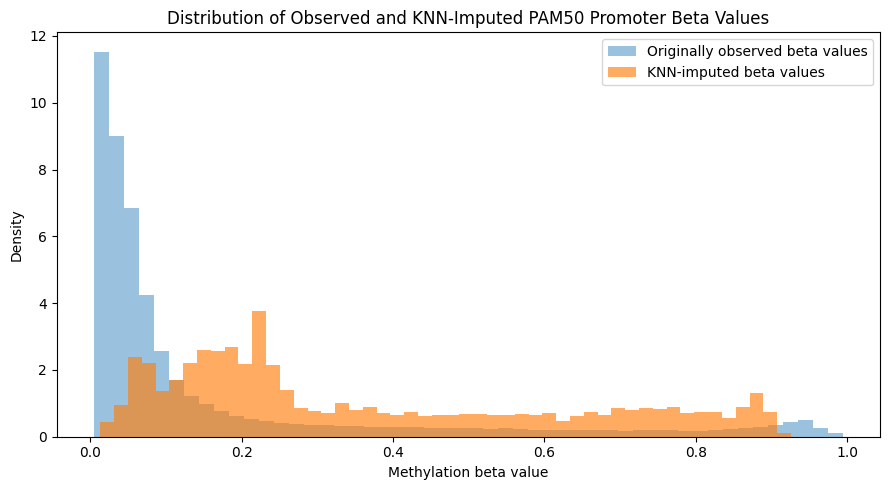

Number of imputed values: 5921
count    5921.000000
mean        0.365518
std         0.260695
min         0.013140
25%         0.158138
50%         0.252706
75%         0.581323
max         0.925788
dtype: float64


In [8]:
# show what knn actually filled in 
imputed_mask = meth_for_imputation.isna()

imputed_values = meth_imputed.where(imputed_mask).to_numpy().ravel()
imputed_values = imputed_values[~np.isnan(imputed_values)]

observed_values = meth_for_imputation.to_numpy().ravel()
observed_values = observed_values[~np.isnan(observed_values)]

plt.figure(figsize=(9, 5))

plt.hist(
    observed_values,
    bins=50,
    density=True,
    alpha=0.45,
    label="Originally observed beta values"
)

plt.hist(
    imputed_values,
    bins=50,
    density=True,
    alpha=0.65,
    label="KNN-imputed beta values"
)

plt.xlabel("Methylation beta value")
plt.ylabel("Density")
plt.title("Distribution of Observed and KNN-Imputed PAM50 Promoter Beta Values")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/figures/observed_vs_imputed_beta_distribution.png",
    dpi=300
)

plt.show()

print("Number of imputed values:", len(imputed_values))
print(pd.Series(imputed_values).describe())

In [9]:
# check that mean values are not shifted too much by imputation
mean_before = meth_for_imputation.mean(axis=0, skipna=True)
mean_after = meth_imputed.mean(axis=0)

mean_shift = (mean_after - mean_before).abs().sort_values(ascending=False)

print(mean_shift.describe())
print(mean_shift.head(10))

count    527.000000
mean       0.000535
std        0.002988
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.035438
dtype: float64
cg05958127    0.035438
cg23795893    0.024354
cg01715172    0.023659
cg07189962    0.022087
cg19449067    0.020581
cg07619683    0.019445
cg08161546    0.013431
cg10406295    0.013359
cg07584093    0.012914
cg01321962    0.011048
dtype: float64


In [10]:
# save summary of imputation results
imputation_summary = pd.DataFrame({
    "metric": [
        "patients",
        "promoter_CpGs",
        "promoter_CpGs_imputed",
        "KNN_neighbors",
        "missing_values_before",
        "missing_values_after",
        "overall_missing_fraction_before",
        "min_beta_after_imputation",
        "max_beta_after_imputation"
    ],
    "value": [
        meth.shape[0],
        meth.shape[1],
        meth_imputed.shape[1],
        k,
        int(meth.isna().sum().sum()),
        int(meth_imputed.isna().sum().sum()),
        meth.isna().mean().mean(),
        meth_imputed.min().min(),
        meth_imputed.max().max()
    ]
})

imputation_summary.to_csv(
    "../results/tables/knn_imputation_summary.csv",
    index=False
)

display(imputation_summary)

,metric,value
0,patients,563.000000
1,promoter_CpGs,572.000000
2,promoter_CpGs_imputed,527.000000
3,KNN_neighbors,10.000000
4,missing_values_before,31256.000000
5,missing_values_after,0.000000
6,overall_missing_fraction_before,0.097057
7,min_beta_after_imputation,0.005173
8,max_beta_after_imputation,0.994024
